In [1]:
# https://paperswithcode.com/search?q_meta=&q_type=&q=semi+supervised+anomaly+detection

### SSLAL
- This notebook experiments how label spreading improves the performance for  semi-supervised techniques.
- The goal is to simulate a scenario where a model is trained iteratively by selecting the most informative data points to label [tehy are randomly selected in this scenario], and using **Label Spreading** to propagate labels from a small set of labeled data to a larger set of unlabeled data.

The approach includes the following steps:
- we start by randomly selecting a small fraction of labeled data points from the dataset.
- Then, we apply active learning to iteratively select the most uncertain or informative data points (to be changed in future, as at now it just random) for labeling.
   - In the semi-supervised learning process, we use **Label Spreading**, to propagates labels from a small set of labeled points to the unlabeled data points, based on their similarity.
   - This helps in cleaning the dataset by removing outliers and refining the model's training data.
   - The model's performance is evaluated using metrics like **ROC-AUC**, where we have both with spreading and not spreading
   - We vary the fraction of labeled data and observe how the model’s performance (ROC-AUC) changes with different amounts of labeled and unlabeled data.




In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.semi_supervised import LabelSpreading, LabelPropagation
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns


from pyod.models.pca import PCA
from pyod.models.ocsvm import OCSVM
from pyod.models.lof import LOF
from pyod.models.cof import COF
from pyod.models.hbos import HBOS
from pyod.models.knn import KNN
from pyod.models.sod import SOD
from pyod.models.copod import COPOD
from pyod.models.ecod import ECOD
from pyod.models.iforest import IForest
from pyod.models.loda import LODA
from pyod.models.kde import KDE
from pyod.models.cblof import CBLOF


import warnings
warnings.filterwarnings("ignore")


In [3]:
model_dict = {
    'PCA': PCA,
    'OCSVM': OCSVM,
    'LOF': LOF,
    'COF': COF,
    'HBOS': HBOS,
    'KNN': KNN,
    'SOD': SOD,
    'COPOD': COPOD,
    'ECOD': ECOD,
    'IForest': IForest,
    'LODA': LODA,
    'KDE': KDE,
    'CBLOF': CBLOF
}

In [38]:
# model1 = LabelSpreading(alpha = 0.0)
# model1.fit(X)

In [4]:
def prepare_data(X, y, num_samples, frac, random_state=42):

    
    _, Xsamp, _, ysamp = train_test_split(X, y, test_size=num_samples / X.shape[0], 
                                           random_state=random_state, stratify=y)

    X_train, X_test, y_train, y_test = train_test_split(Xsamp, ysamp, test_size=0.5,                                                         
                                                        random_state=random_state, stratify=ysamp)
    data_dict = {
        "xprop": X_train,
        "yprop": y_train,
        "xspread": X_train,
        "yspread": y_train,
        "xno": X_train,
        "yno": y_train,
        "x": X_train,
        "y": y_train,
        "xtest": X_test,
        "ytest": y_test,
    }
    if frac > 0:
        # lbl spreading to remove outliers
        label_spread_model = LabelSpreading(alpha = 0.00001)
        label_prop_model = LabelPropagation()
        
        rng = np.random.RandomState(random_state)
        random_unlabeled_points = rng.rand(len(y_train)) > frac
        labels = np.copy(y_train)
        #unlabeleld with -1
        labels[random_unlabeled_points] = -1

        # Check if we have enough labeled points before fitting
        if np.sum(labels != -1) < 2:
            print(f"Warning: Not enough labeled points after applying fraction {frac}. Skipping label spreading.")
            return data_dict  # Return data without label spreading
           
            
        label_spread_model.fit(X_train, labels)
        # get predicted probabilities for outliers
        label_proba_spread = label_spread_model.predict_proba(X_train)
        
        label_prop_model.fit(X_train, labels)
        label_proba_prop = label_prop_model.predict_proba(X_train)

        

        # remove outliers based on probability threshold
        random_values = rng.rand(len(y_train))
        remove_idx_spread = np.where(label_proba_spread[:, 0] < random_values)[0]
        X_train_spread = np.delete(X_train, remove_idx_spread, axis=0)
        y_train_spread = np.delete(y_train, remove_idx_spread)
        data_dict["xspread"] = X_train_spread
        data_dict["yspread"] = y_train_spread
            

        remove_idx_prop = np.where(label_proba_prop[:, 0] < random_values)[0]
        X_train_prob = np.delete(X_train, remove_idx_prop, axis=0)
        y_train_prop = np.delete(y_train, remove_idx_prop)
        data_dict["xprop"] = X_train_prob
        data_dict["yprop"] = y_train_prop

        

        # remove points that are labeled as "not outliers" (i.e., labeled as 1)
        remove_idx_noprop = np.where(labels == 1)[0]
        X_train_noprop = np.delete(X_train, remove_idx_noprop, axis=0)
        y_train_noprop = np.delete(y_train, remove_idx_noprop)

        data_dict["xno"] = X_train_noprop
        data_dict["yno"] = y_train_noprop

    else:
        # no label spreading, use full data
        pass
    

    return data_dict

In [5]:


def train_and_evaluate(data_dict, model, model_name, params={}):

    detector_prop = model(**params)
    detector_noprop = model(**params)
    detector_spread = model(**params)
    
    
    #extratct the data
    xprop = data_dict.get("xprop")
    yprop = data_dict.get("yprop")
    xspread = data_dict.get("xspread")
    yspread = data_dict.get("yspread")
    xno = data_dict.get("xno")
    yno = data_dict.get("yno")
    xtest = data_dict.get("xtest")
    ytest = data_dict.get("ytest")
    
    
    # train both models
    detector_prop.fit(xprop)
    detector_spread.fit(xspread)
    detector_noprop.fit(xno)

    # get outlier scores (decision function)
    xtest_scores_prop = detector_prop.decision_function(xtest)
    xtest_scores_no = detector_noprop.decision_function(xtest)
    xtest_scores_spread = detector_spread.decision_function(xtest)



    # find ROC-AUC scores
    try:
        roc_auc_prop = roc_auc_score(ytest, xtest_scores_prop)
        roc_auc_spread = roc_auc_score(ytest, xtest_scores_spread)
        roc_auc_noprop = roc_auc_score(ytest, xtest_scores_no)
    except ValueError as e:
        print(f"Error occured while getting the auc values : e={e}")
        # handle error cases where AUC cannot be calculated E.G single class in the test set
        roc_auc_prop = np.nan
        roc_auc_spread = np.nan
        roc_auc_noprop = np.nan
    
    return roc_auc_noprop, roc_auc_prop, roc_auc_spread


In [25]:
def run_experiment(X, y, model, model_name, num_samples=1000, fractions=None, random_state=42, reps=5, params={}):
    # init result DataFrames
    results_df = pd.DataFrame()
    
    # loop over different fractions of outliers
    for frac in tqdm(fractions):
        for rep in range(reps):
            # prepare data with different outlier fractions
            try:
                data_dict = prepare_data(
                    X, y, num_samples, frac, random_state=random_state + rep)
                # train and evaluate the model
                roc_auc_noprop, roc_auc_prop, roc_auc_spread = train_and_evaluate(
                    data_dict, model, model_name, params
                )
    
                # store results for label spreading and no label spreading models
                result_prop = {'method': 'Spreading', 'model': model_name, 'roc_auc': roc_auc_prop, 'fraction': frac, 'rep': rep}
                result_df_prop = pd.DataFrame(result_prop, index=[0])
                results_df = pd.concat([results_df, result_df_prop])

                result_spread = {'method': 'Propagation', 'model': model_name, 'roc_auc': roc_auc_spread, 'fraction': frac, 'rep': rep}
                result_df_spread = pd.DataFrame(result_spread, index=[0])
                results_df = pd.concat([results_df, result_df_spread])
                
    
                result_noprop = {'method': 'No Spreading', 'model': model_name, 'roc_auc': roc_auc_noprop, 'fraction': frac, 'rep': rep}
                result_df_noprop = pd.DataFrame(result_noprop, index=[0])
                results_df = pd.concat([results_df, result_df_noprop])
            except Exception as e:
                # raise
                print(f"Error: {e} at model={model_name}, ")

    return results_df


In [7]:
model_dict, len(model_dict)

({'PCA': pyod.models.pca.PCA,
  'OCSVM': pyod.models.ocsvm.OCSVM,
  'LOF': pyod.models.lof.LOF,
  'COF': pyod.models.cof.COF,
  'HBOS': pyod.models.hbos.HBOS,
  'KNN': pyod.models.knn.KNN,
  'SOD': pyod.models.sod.SOD,
  'COPOD': pyod.models.copod.COPOD,
  'ECOD': pyod.models.ecod.ECOD,
  'IForest': pyod.models.iforest.IForest,
  'LODA': pyod.models.loda.LODA,
  'KDE': pyod.models.kde.KDE,
  'CBLOF': pyod.models.cblof.CBLOF},
 13)

In [8]:

# for a single plot
def plot_single_results_with_uncertainty(results_df, fractions, model_name, dataset):

    plt.figure(figsize=(15, 10))
    sns.lineplot(x='fraction', y='roc_auc', data=results_df, errorbar='sd', hue='method', style='method')

    plt.title(f'{model_name} on {dataset}, Random Querying')
    plt.ylabel('AUC')
    plt.xlabel('% labels queried')

    ax = plt.gca()
    ax.set_xticks(fractions)
    ax.set_xticklabels([f'{x*100:.0f}%' if x >= 0.1 or x == 0 else '' for x in fractions])

    plt.xlim(-.01, 1.01)

    plt.legend(title='Method')
    plt.tight_layout()
    plt.show()


# grid
import math
def plot_results_grid(all_results, fractions, model_dict, datasets):
    num_datasets = len(datasets)
    num_models = len(model_dict)
    
    for i, dataset in enumerate(datasets):
        cols = 4 #we have 4 cols
        rows = math.ceil(num_models/cols)
        
        fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
        axes = axes.flatten()  # Flatten to make it easier to index axes

        for j, (model_name, model) in enumerate(model_dict.items()):
            # filter the results for the current dataset and model
            dataset_model_results = all_results[(all_results['dataset'] == dataset) & (all_results['model'] == model_name)].dropna().reset_index(drop=True)
            ax = axes[j]
            sns.lineplot(x='fraction', y='roc_auc', data=dataset_model_results, errorbar='sd', hue='method', style='method', ax=ax)
            ax.set_title(f'{model_name} on {dataset}', fontsize=14, fontweight='bold')
            ax.set_ylabel('AUC')
            ax.set_xlabel('% labels queried')
            ax.set_xticks(fractions)
            ax.set_xticklabels([f'{x * 100:.0f}%' if x >= 0.1 or x == 0 else '' for x in fractions])
            ax.set_xlim(-.01, 1.01)
        print("DOne for dataset ", dataset)

        plt.suptitle(f"ROC_AUC score comparisons for diffent model using {dataset} dataset", y=1.03, fontweight='bold', fontsize=15)
        plt.tight_layout()
        plt.show()


In [19]:
# test
dataset = '33_skin'
path = f'data/{dataset}.npz'
data = np.load(path, allow_pickle=True)
X, y = data['X'], data['y']

# define fractions for outlier removal
fractions = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09,
             0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0]


all_results = pd.DataFrame()
for each_key, each_model in model_dict.items():
    all_results_scores = run_experiment(X, y, each_model, each_key, fractions=fractions)
    all_results_scores["dataset"] = dataset
    all_results = pd.concat([all_results, all_results_scores])
    # plot_single_results_with_uncertainty(all_results_scores, fractions, each_key, dataset)

  6%|██▌                                         | 1/17 [00:00<00:14,  1.13it/s]

  6%|██▌                                         | 1/17 [00:01<00:18,  1.16s/it]

  6%|██▌                                         | 1/17 [00:00<00:12,  1.27it/s]

  6%|██▌                                         | 1/17 [00:04<01:11,  4.49s/it]

  6%|██▌                                         | 1/17 [00:00<00:10,  1.51it/s]

...

  6%|██▌                                         | 1/17 [00:04<01:08,  4.28s/it]

  6%|██▌                                         | 1/17 [00:01<00:18,  1.18s/it]

  6%|██▌                                         | 1/17 [00:01<00:26,  1.63s/it]

  6%|██▌                                         | 1/17 [00:01<00:16,  1.05s/it]

100%|███████████████████████████████████████████| 17/17 [00:44<00:00,  2.61s/it]


In [21]:
all_results["model"].unique()

array(['PCA', 'OCSVM', 'LOF', 'COF', 'HBOS', 'KNN', 'SOD', 'COPOD',
       'ECOD', 'IForest', 'LODA', 'KDE', 'CBLOF'], dtype=object)

DOne for dataset  33_skin


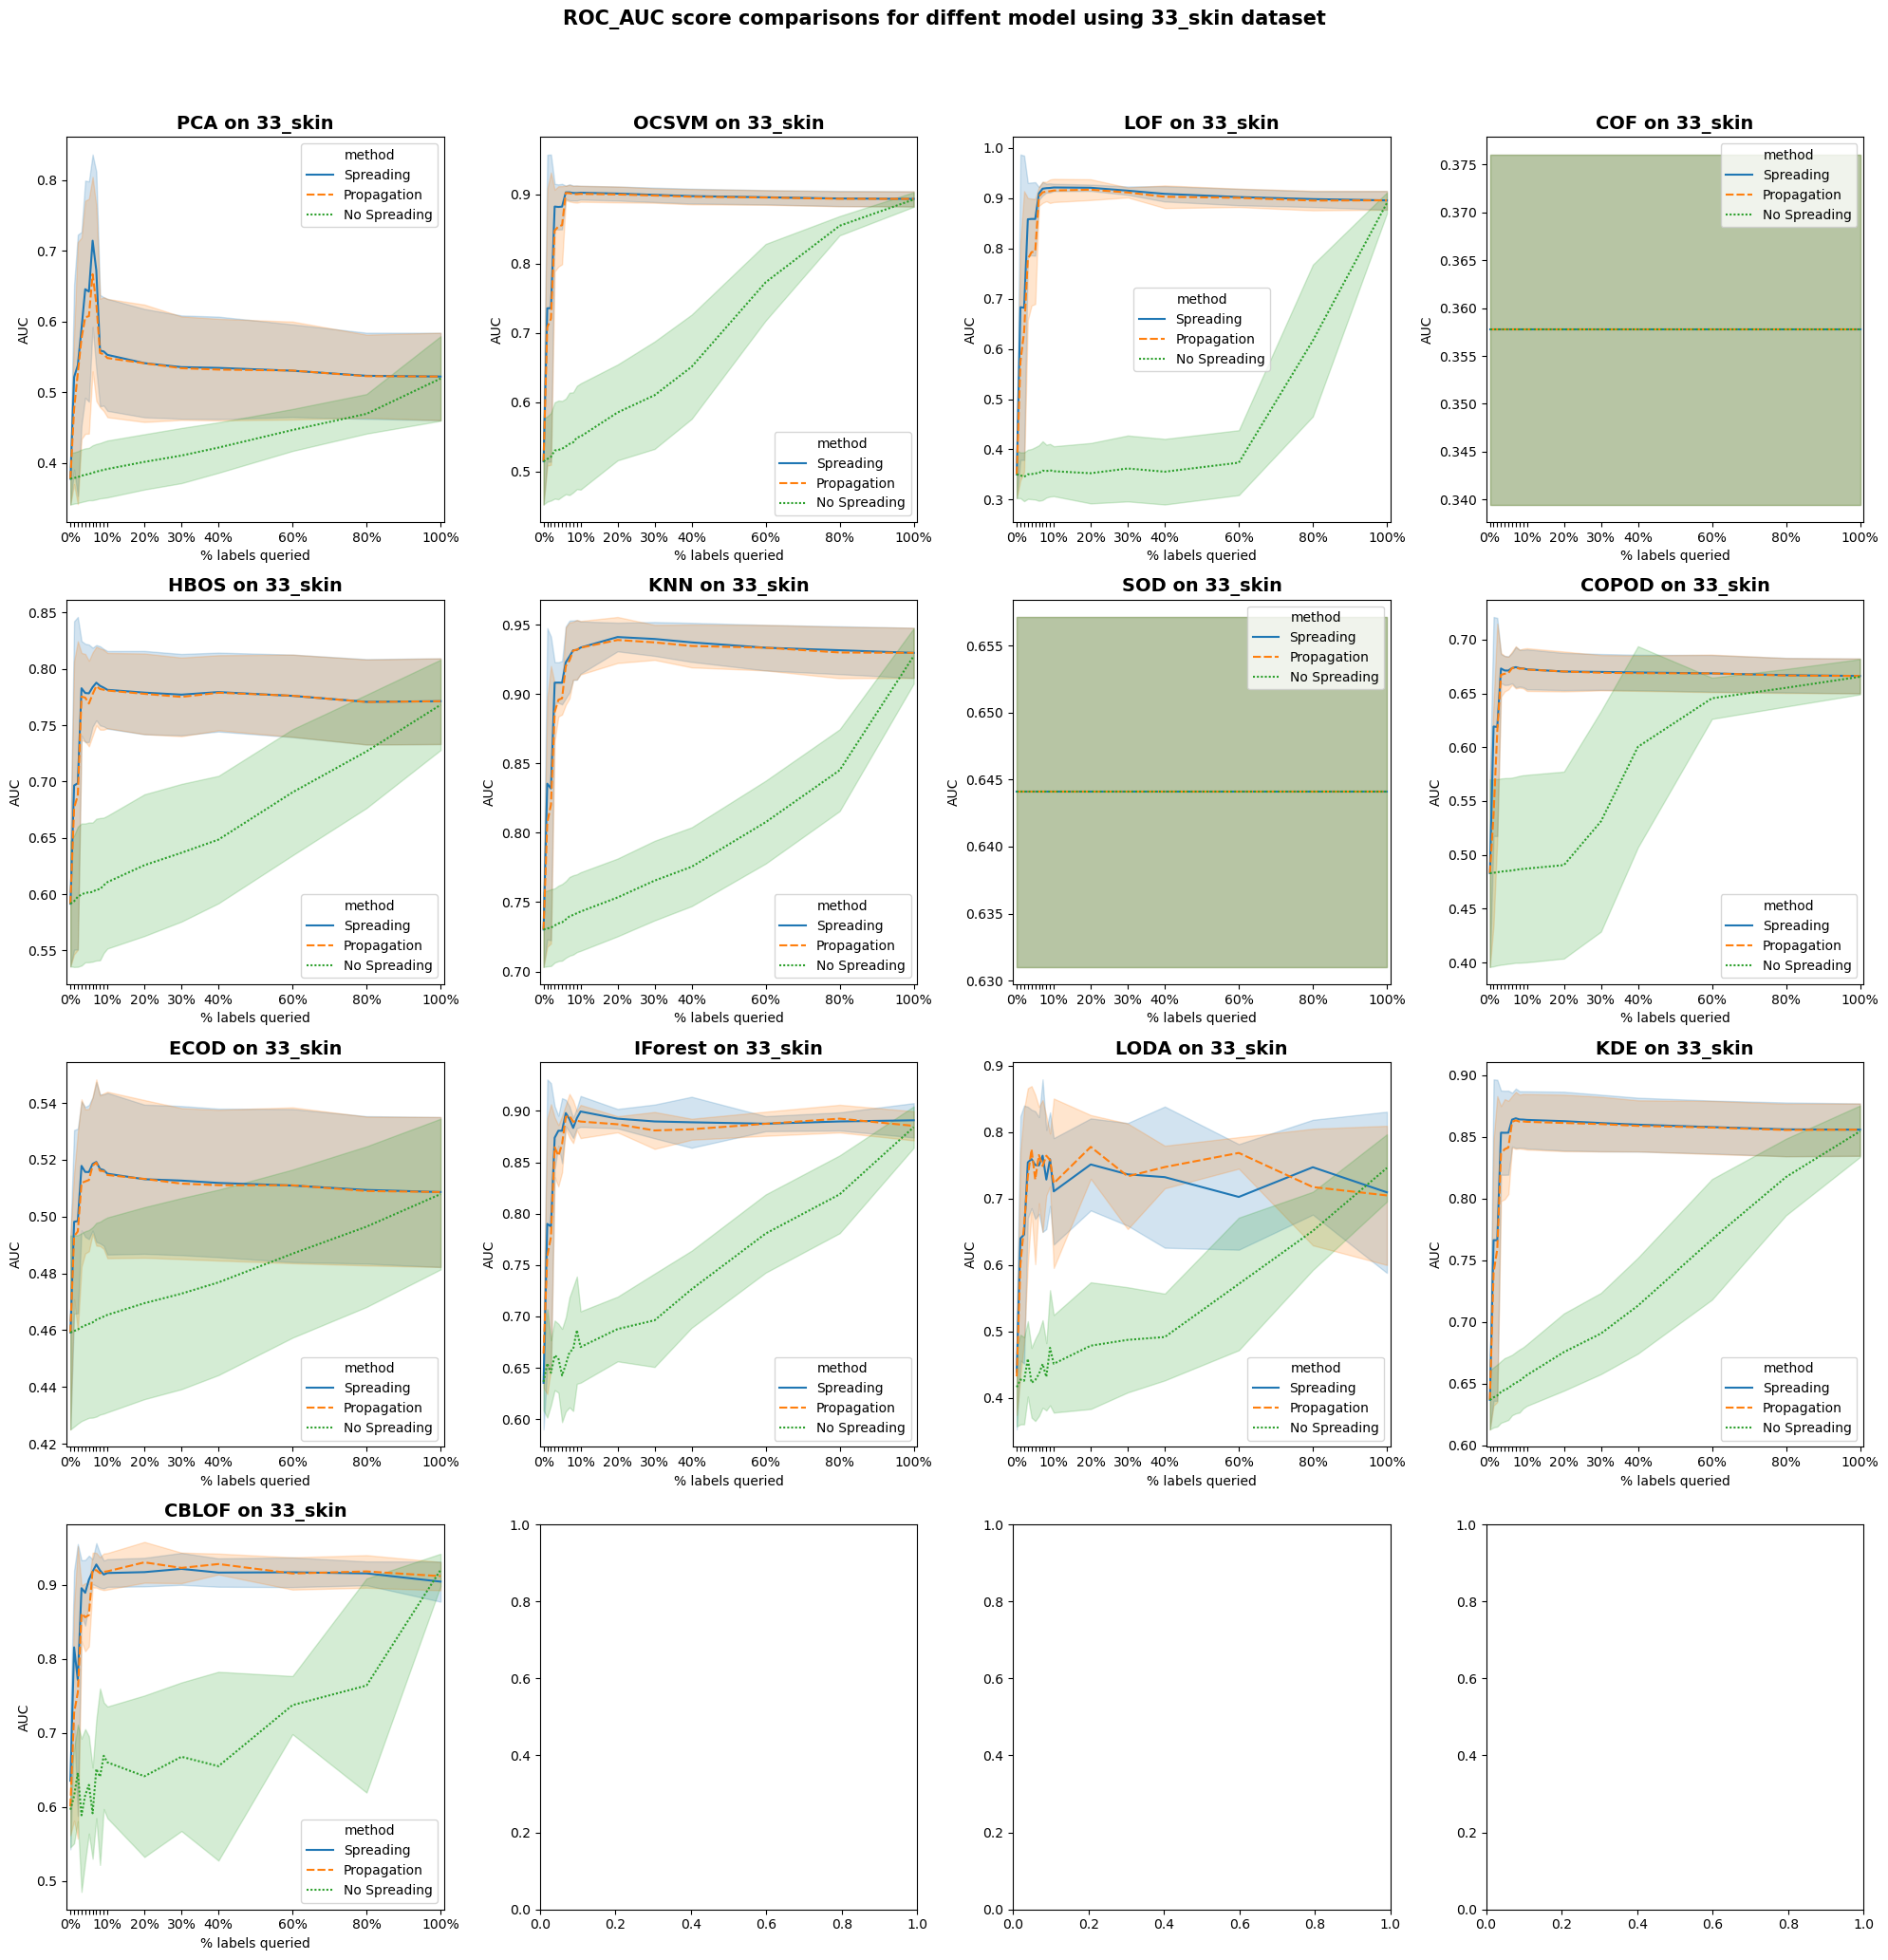

In [24]:
# plot
plot_results_grid(all_results, fractions, model_dict, all_results["dataset"].unique().tolist())

In [ ]:
# SOD and COF not perfoming as both prop/no prop does not change or improve with frac
# try it with some params

In [ ]:
pd.DataFrame(X).describe().T

In [ ]:
# # method=fast/memory
# # cof_model = COF(n_neighbors=5, method='memory')
# cof_model = COF
# cof_results_ = run_experiment(X, y, cof_model, "COF", fractions=fractions, params= {"method": "memory", "n_neighbors": 5})
# plot_single_results_with_uncertainty(cof_results_, fractions, "COF", dataset)

In [ ]:
# # sns.distplot(X[:, 0])

# from sklearn.preprocessing import StandardScaler, MinMaxScaler

# scaler = StandardScaler()

# X_scaled = scaler.fit_transform(X)

In [ ]:
# # scaled
# cof_results_prop, cof_results_noprop = run_experiment(X_scaled, y, cof_model, "COF", fractions=fractions, params= {"method": "memory", "n_neighbors": 5})
# plot_single_results_with_uncertainty(cof_results_prop, cof_results_noprop, fractions, "COF", dataset)

In [ ]:
# run all dataset to check if the same is observed on them

In [26]:
# run for several dataset
dataset_subset = ['11_donors', '2_annthyroid', '6_cardio', '7_Cardiotocography']
fractions = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09,
                 0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0]
all_results = pd.DataFrame()
for dataset in dataset_subset:
    path = f'data/{dataset}.npz'
    data = np.load(path, allow_pickle=True)
    X, y = data['X'], data['y']
    for each_key, each_model in model_dict.items():
        current_results = run_experiment(X, y, each_model, each_key, fractions=fractions)
        current_results["dataset"] = dataset
        #combine
        all_results = pd.concat([all_results, current_results])
        print("Current datasets are ", all_results["dataset"].unique())
    


  6%|██▌                                         | 1/17 [00:02<00:47,  2.94s/it]

100%|███████████████████████████████████████████| 17/17 [00:51<00:00,  3.05s/it]


Current datasets are  ['11_donors']


  6%|██▌                                         | 1/17 [00:02<00:43,  2.74s/it]

100%|███████████████████████████████████████████| 17/17 [00:56<00:00,  3.35s/it]


...

100%|███████████████████████████████████████████| 17/17 [00:26<00:00,  1.54s/it]


Current datasets are  ['11_donors' '2_annthyroid' '6_cardio' '7_Cardiotocography']


  6%|██▌                                         | 1/17 [00:00<00:13,  1.16it/s]

100%|███████████████████████████████████████████| 17/17 [00:22<00:00,  1.35s/it]

Current datasets are  ['11_donors' '2_annthyroid' '6_cardio' '7_Cardiotocography']


In [30]:
all_results["dataset"].unique().tolist()

['11_donors', '2_annthyroid', '6_cardio', '7_Cardiotocography']

In [31]:
all_results[all_results["dataset"]=="6_cardio"]

,method,model,roc_auc,fraction,rep,dataset
0,Spreading,PCA,NaN,0.0,0,6_cardio
0,Propagation,PCA,NaN,0.0,0,6_cardio
0,No Spreading,PCA,NaN,0.0,0,6_cardio
0,Spreading,PCA,NaN,0.0,1,6_cardio
0,Propagation,PCA,NaN,0.0,1,6_cardio
...,...,...,...,...,...,...
0,Propagation,CBLOF,0.961053,1.0,3,6_cardio
0,No Spreading,CBLOF,0.958518,1.0,3,6_cardio
0,Spreading,CBLOF,0.947317,1.0,4,6_cardio
0,Propagation,CBLOF,0.946350,1.0,4,6_cardio


DOne for dataset  11_donors


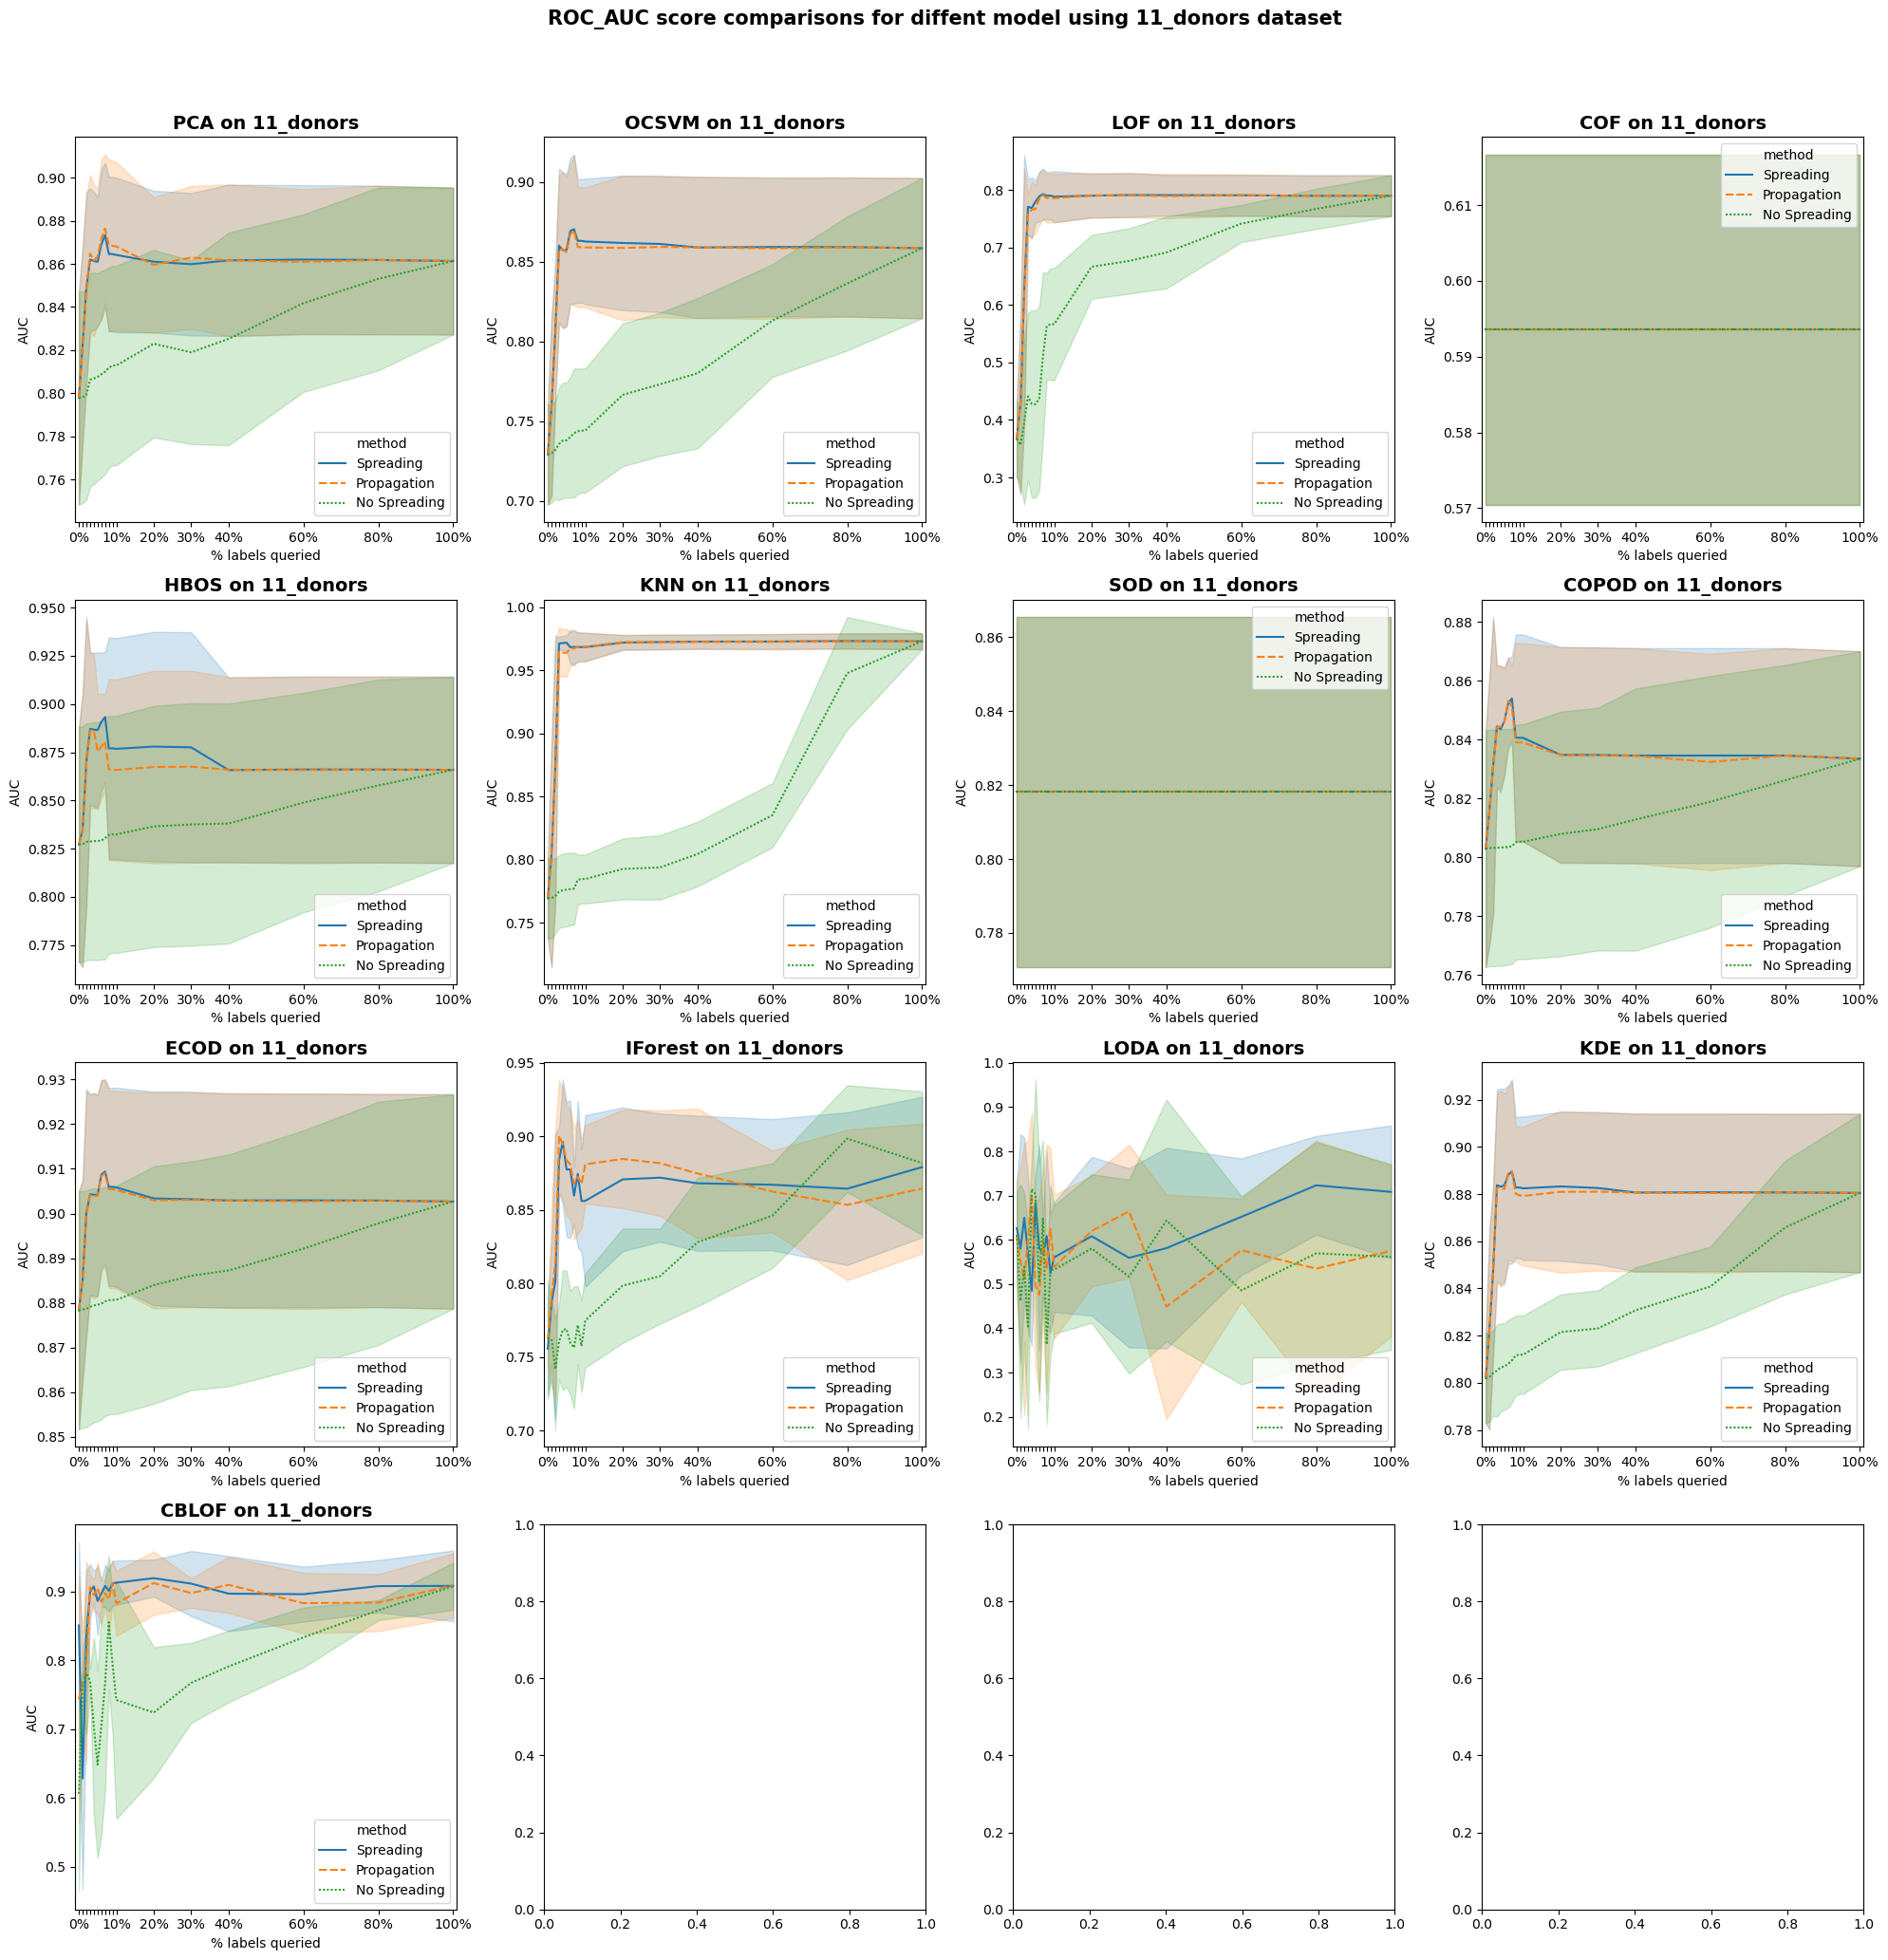

DOne for dataset  2_annthyroid


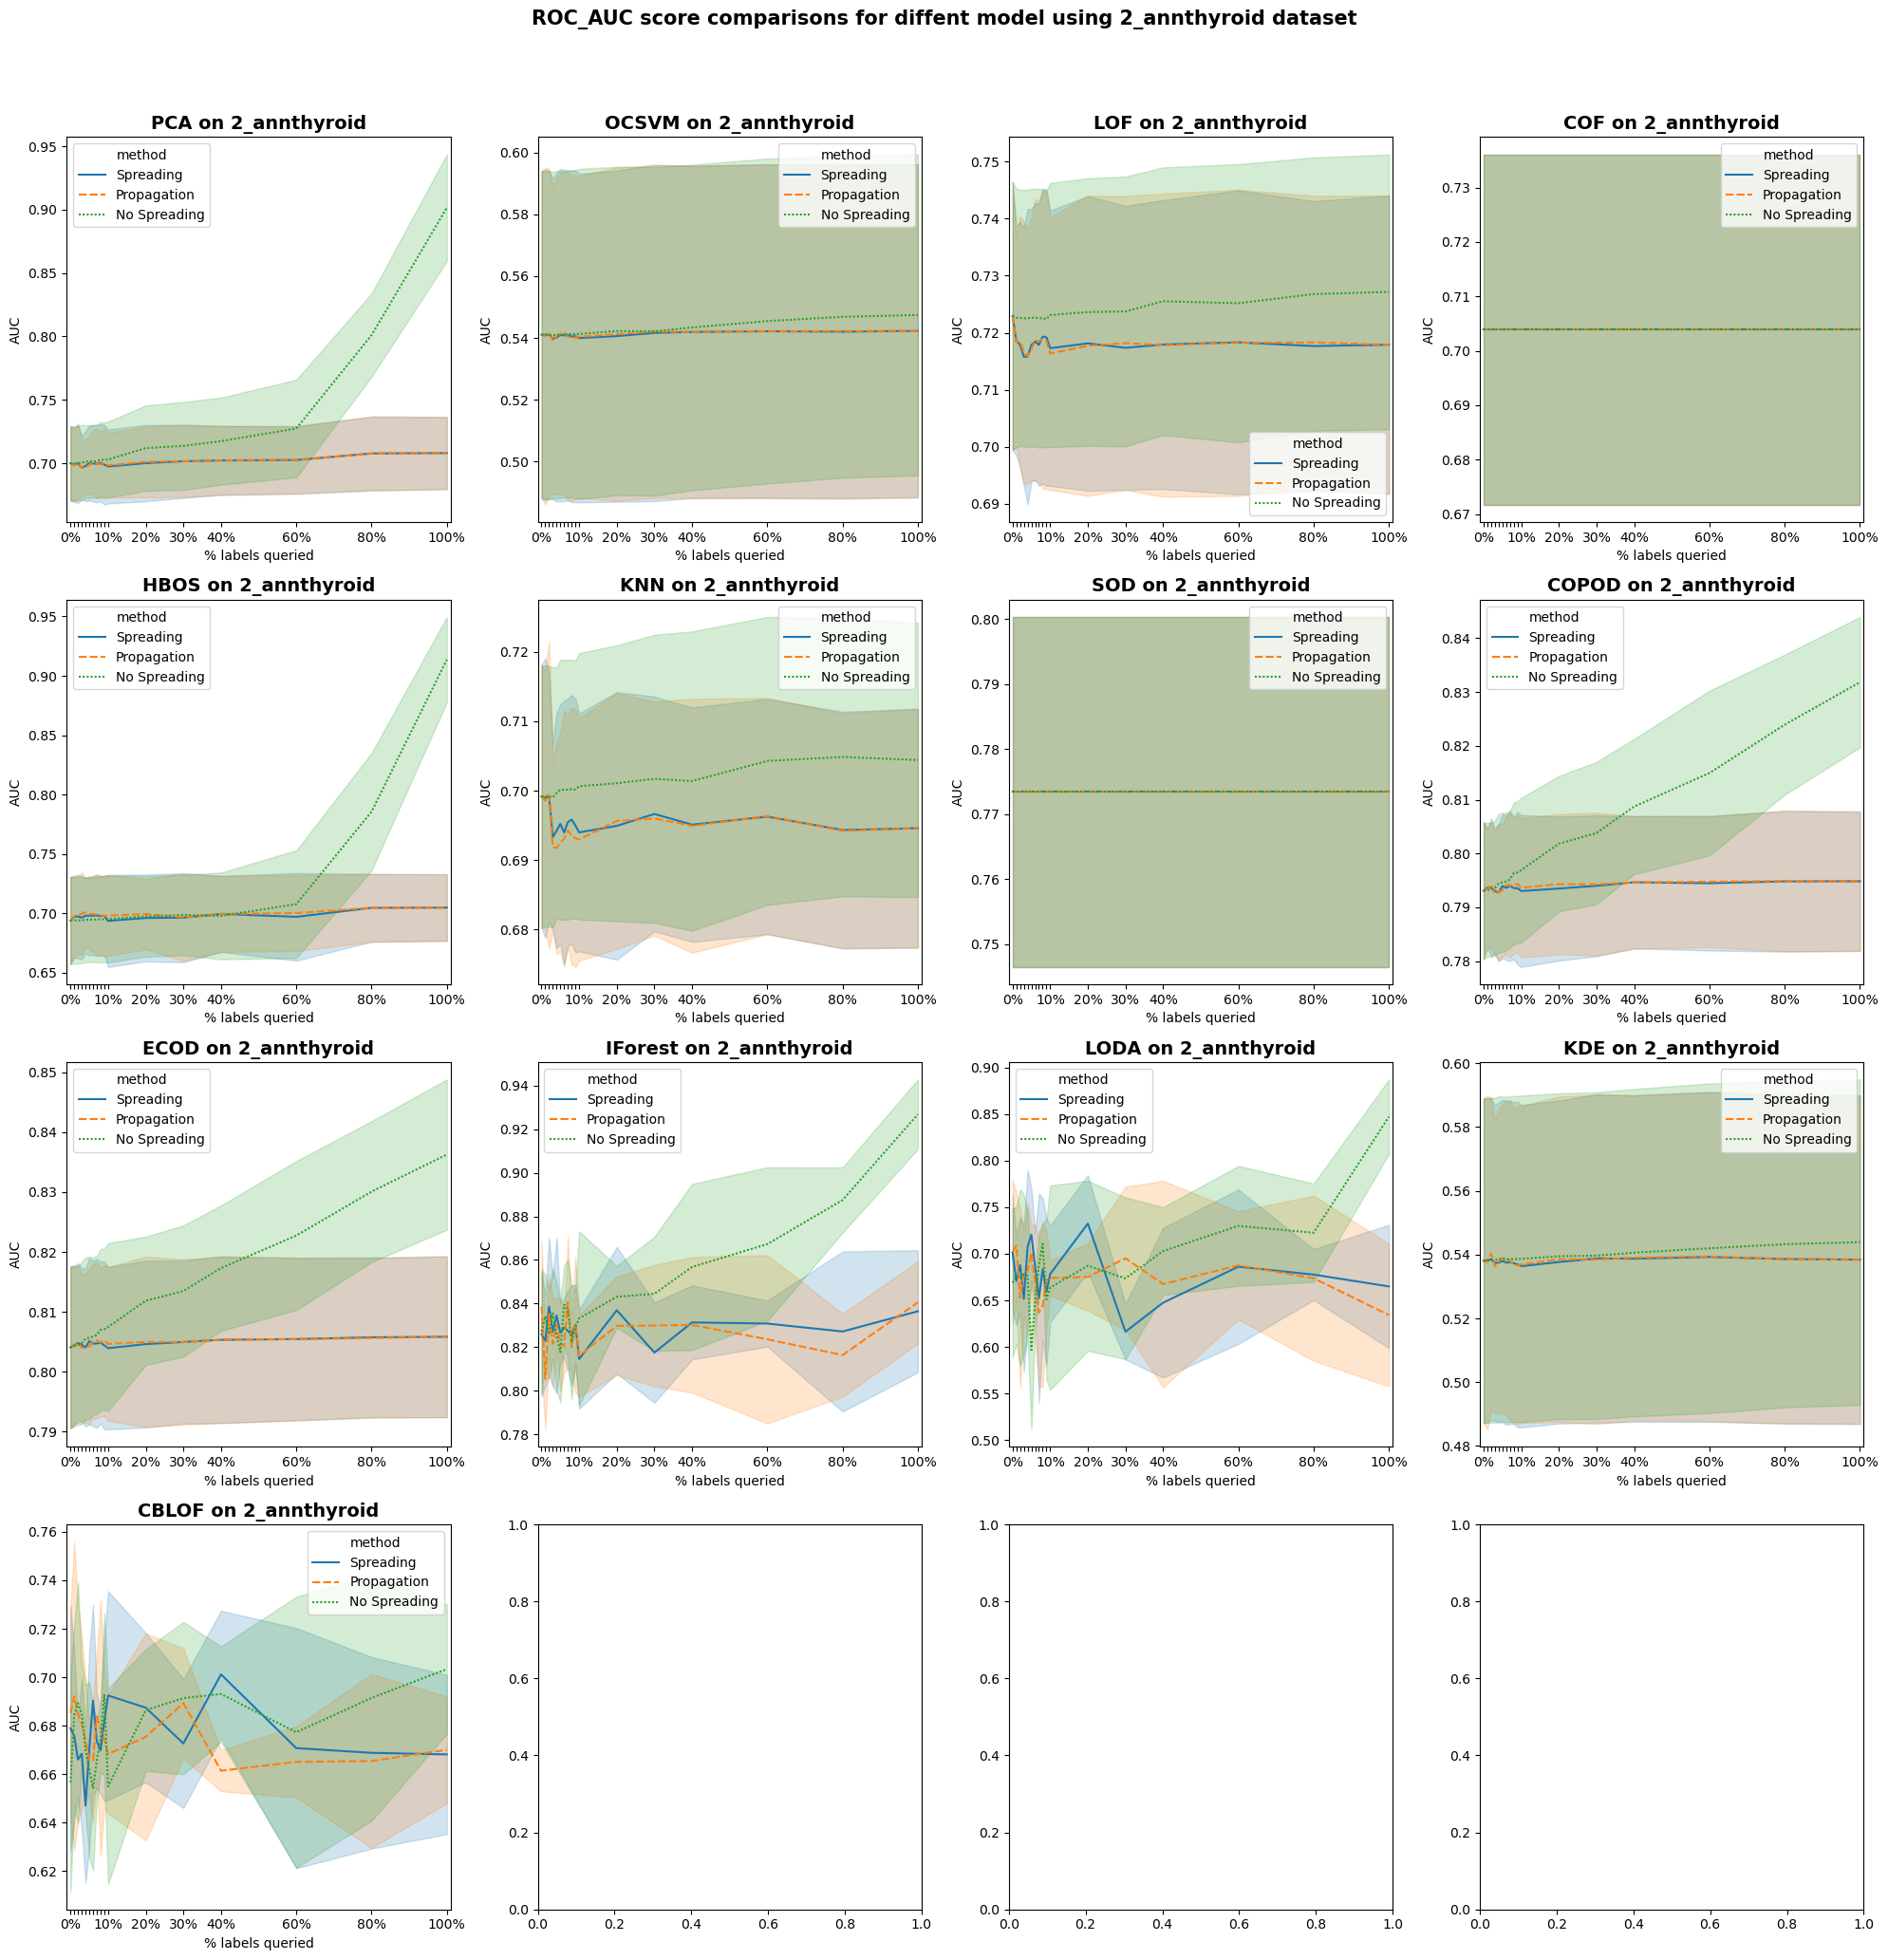

DOne for dataset  6_cardio


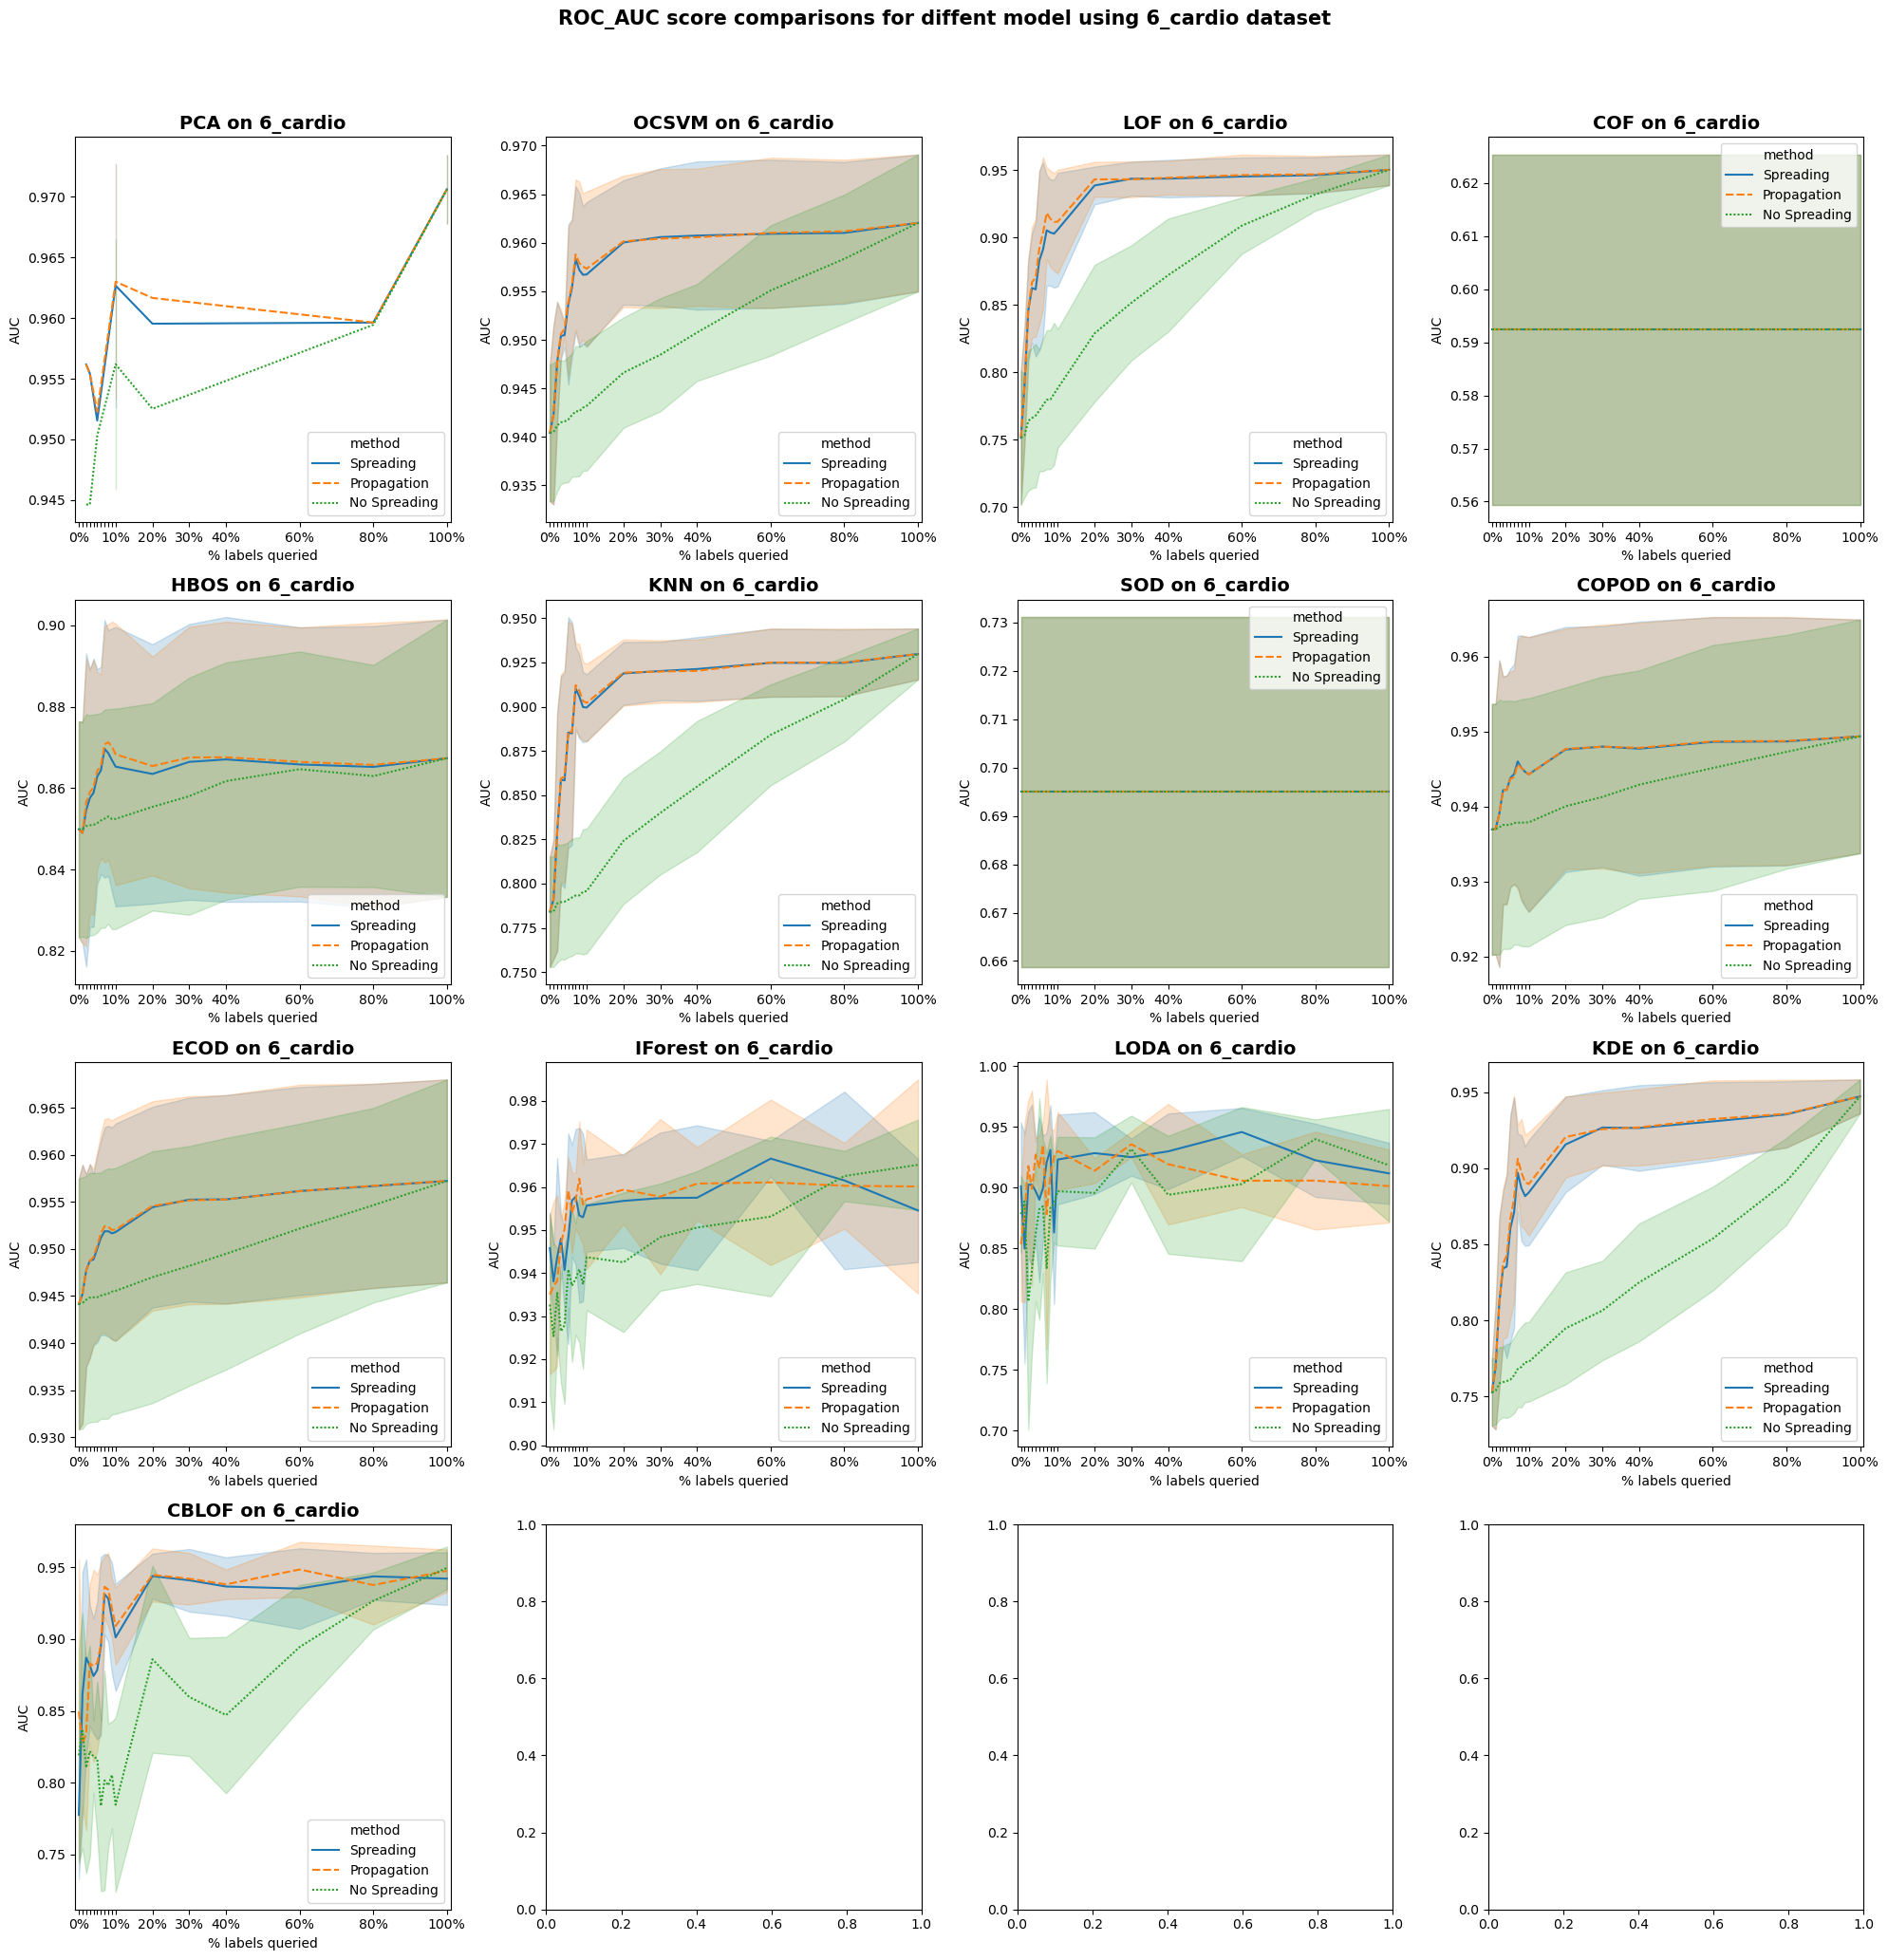

DOne for dataset  7_Cardiotocography


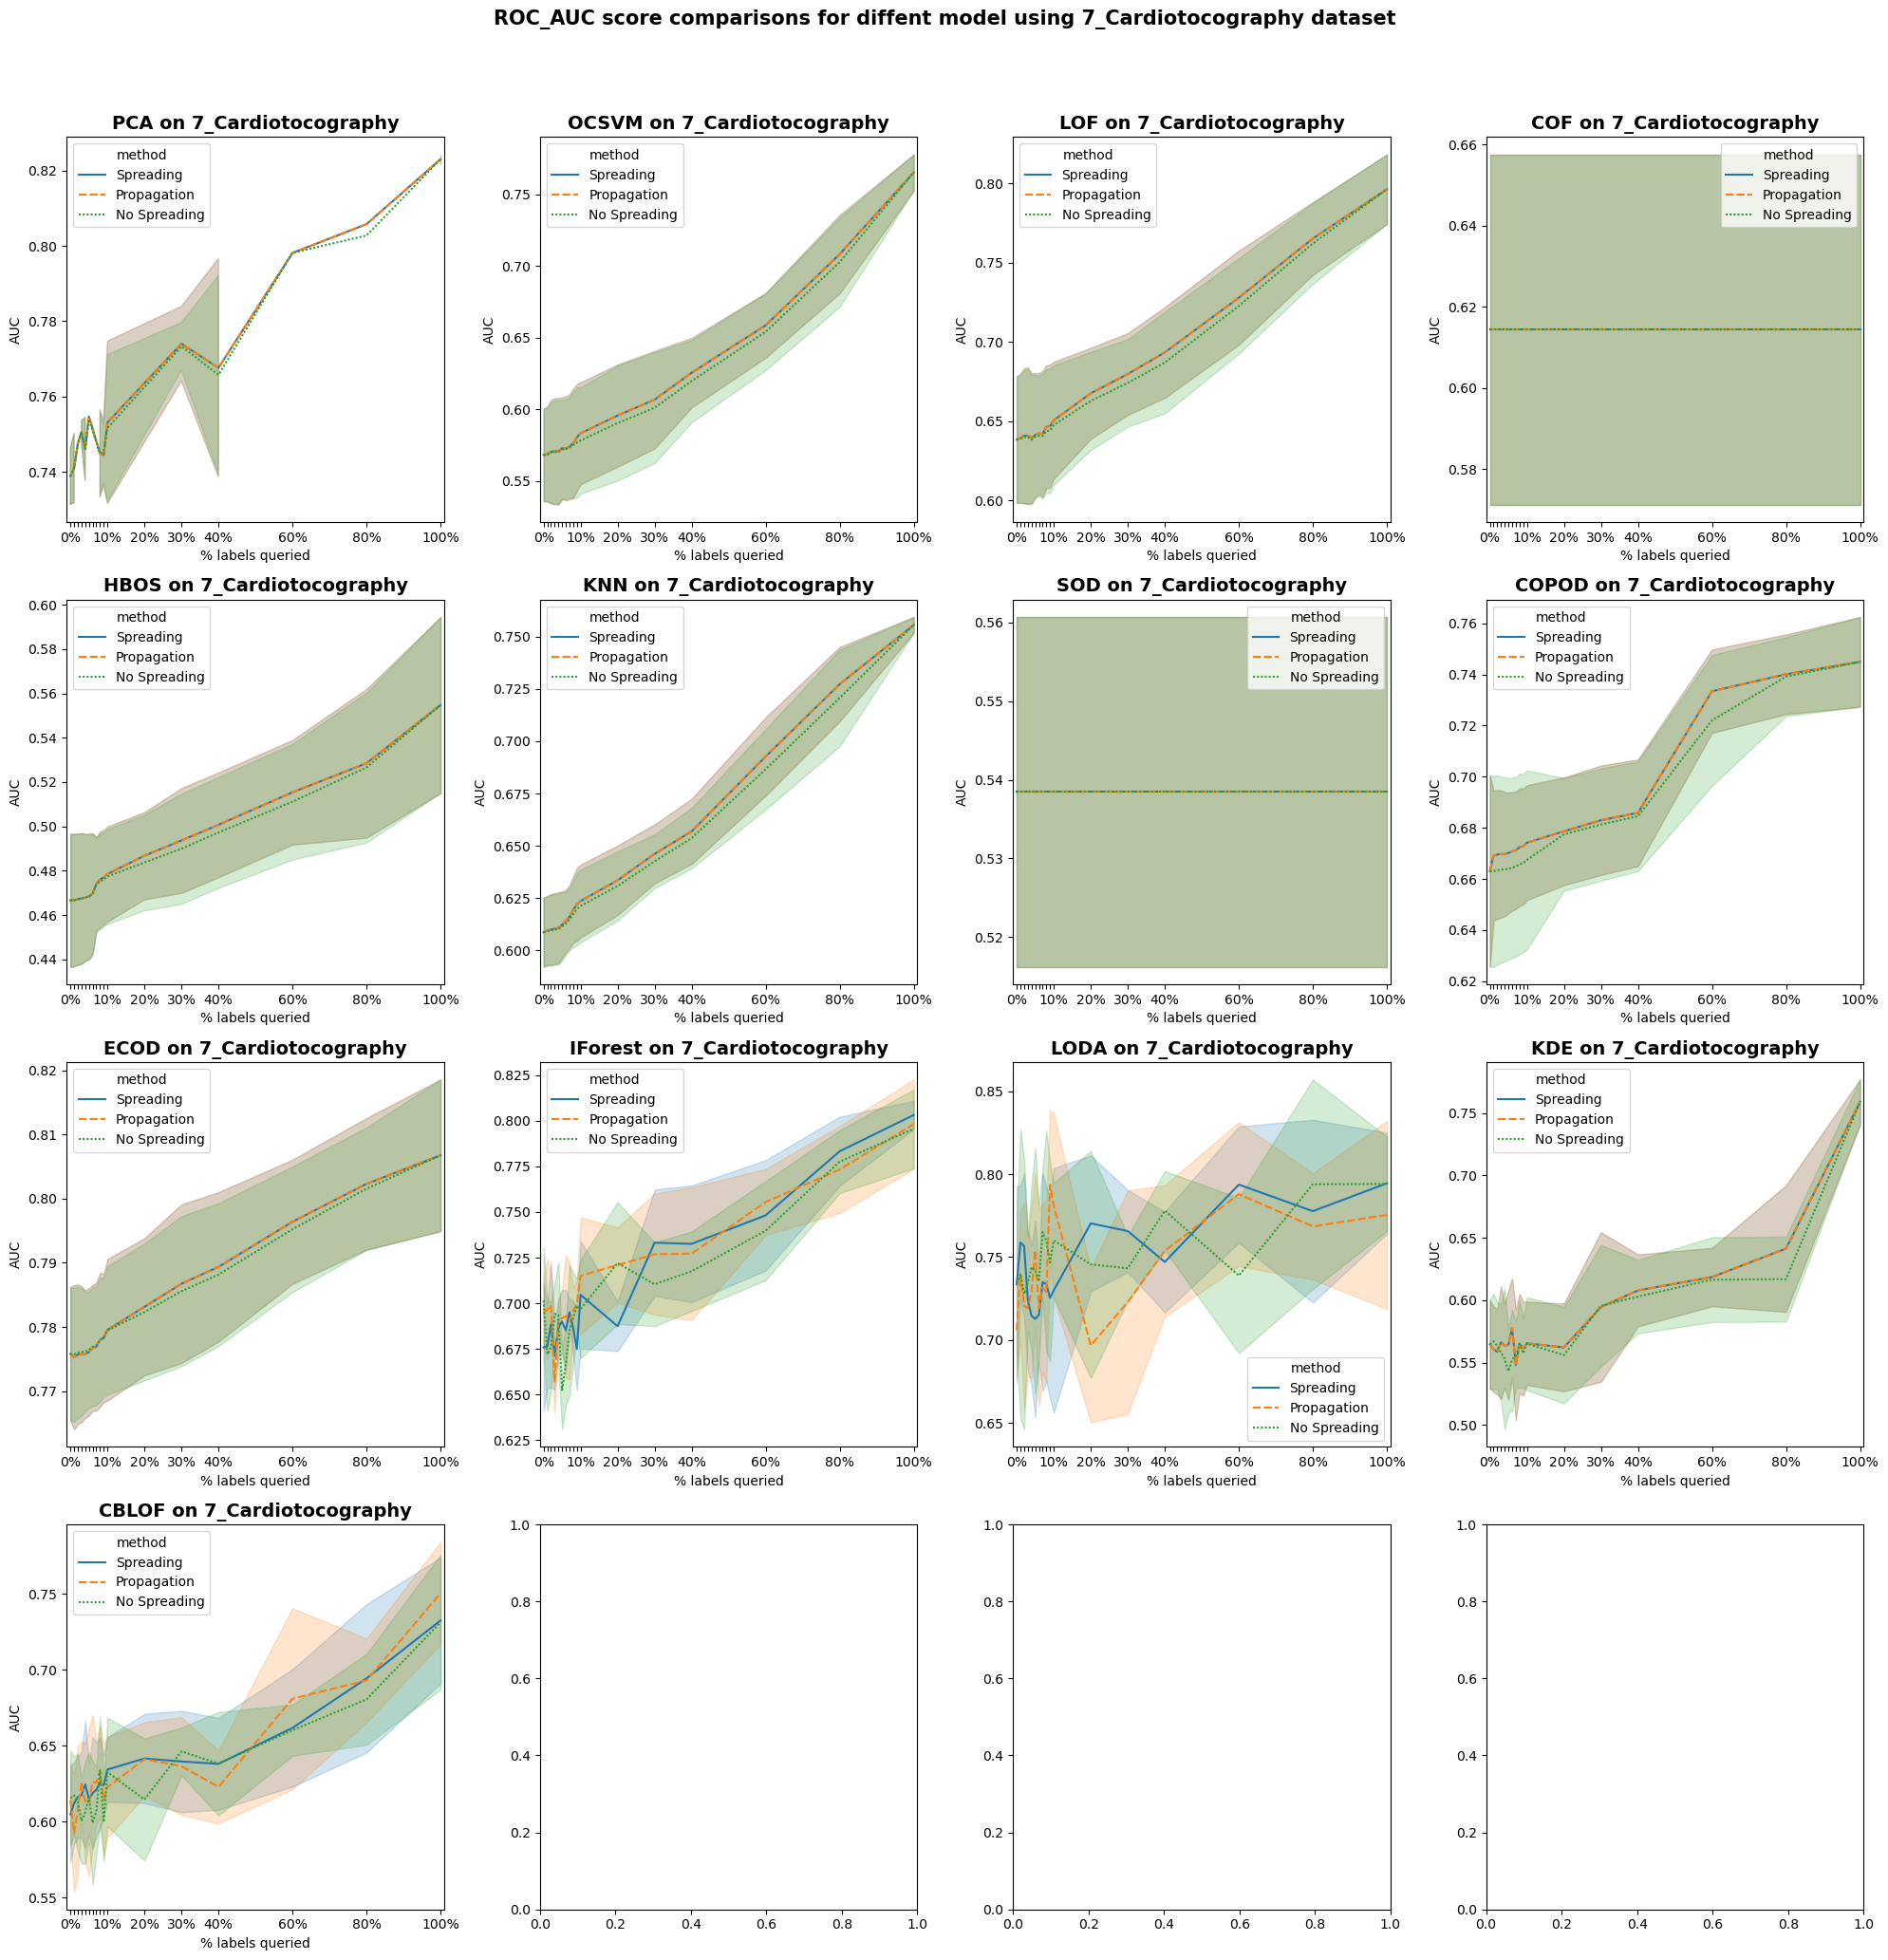

In [32]:
# plot the results
plot_results_grid(all_results, fractions, model_dict, all_results["dataset"].unique().tolist())

In [ ]:
# dataset="2_annthyroid"
# path = f'data/{dataset}.npz'
# data = np.load(path, allow_pickle=True)
# X, y = data['X'], data['y']

# fractions = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09,
#                  0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0]
# cof_results_prop, cof_results_prop1, cof_results_noprop = run_experiment(X, y, IForest, "Iforest", fractions=fractions, params= {"n_estimators": 200})
# plot_single_results_with_uncertainty(cof_results_prop, cof_results_prop1, cof_results_noprop, fractions, "IFOREST", dataset)

In [ ]:
# cof_results_prop, cof_results_prop1, cof_results_noprop = run_experiment(X, y, IForest, "Iforest", fractions=fractions)
# plot_single_results_with_uncertainty(cof_results_prop, cof_results_prop1, cof_results_noprop, fractions, "IFOREST", dataset)

In [39]:
#1.  Clustering using KMeans clustering to identify x clusters and then calculate an outlier score based on distances from the cluster centroids. 
# We can then maybe get percentile/or x std positions etc
# 2. Use distances
# 3. Split dataset into xclusters (look for columns which can be used..) maybe stratified/kfold
# 
# 
# 
# 

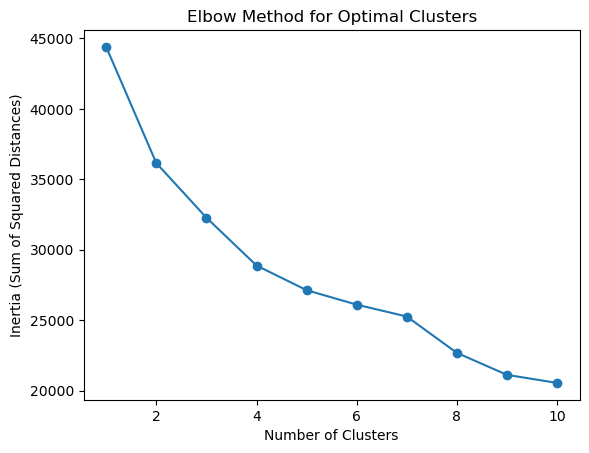

Optimal number of clusters: 10


In [33]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


def determine_optimal_clusters(X_train, max_clusters=10):
    """
    Determine the optimal number of clusters using the Elbow method.
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)
    inertia = []
    for n_clusters in range(1, max_clusters + 1):
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans.fit(X_scaled)
        inertia.append(kmeans.inertia_)

    #plotting
    plt.plot(range(1, max_clusters + 1), inertia, marker='o')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Inertia (Sum of Squared Distances)')
    plt.title('Elbow Method for Optimal Clusters')
    plt.show()

    # we'll use the index where the inertia starts flattening out to decide the number of clusters i,e where inertia stops descreasing as rapidlu.
    # +2 because we start with 1 cluster
    optimal_clusters = np.argmax(np.diff(inertia)) + 2  
    return optimal_clusters

def filter_outliers_by_clustering(X_train, y_train, filter_by="score", random_frac=0.1, random_state=42):
    """
    Clustering-based outlier detection and filtering with dynamic cluster number.
    """
    # get the optimal number of clusters dynamically
    optimal_clusters = determine_optimal_clusters(X_train)
    print(f"Optimal number of clusters: {optimal_clusters}")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    # apply KMeans clustering with the optimal number of clusters
    kmeans = KMeans(n_clusters=optimal_clusters, random_state=random_state)
    y_pred = kmeans.fit_predict(X_scaled)

    # get the distance of each point from its assigned cluster center
    distances = pairwise_distances(X_scaled, kmeans.cluster_centers_, metric='euclidean')
    closest_distances = np.min(distances, axis=1)

    # find outliers based on the filtering method
    if filter_by == "score":
        # score-based filtering to get farthest 10% points from cluster centroid
        outlier_threshold = np.percentile(closest_distances, 90)
        remove_idx = np.where(closest_distances > outlier_threshold)[0]
    elif filter_by == "random":
        # randomly selection of points
        np.random.seed(random_state)
        remove_idx = np.random.choice(len(X_train), size=int(random_frac * len(X_train)), replace=False)
    else:
        raise ValueError("Invalid filter_by method. Choose 'score' or 'random'.")

    return remove_idx
    
def filter_outliers_by_dbscan(X_train, y_train, eps=0.5, min_samples=5, filter_by="score", random_frac=0.1, random_state=42):
    """
    Outlier detection using DBSCAN clustering.
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)

    # points labeled as -1 by DBSCAN are considered outliers
    outlier_idx = np.where(labels == -1)[0]

    # filter based on method (score or random)
    if filter_by == "score":
        # using the distance to the nearest core point as the score
        core_points = np.where(labels != -1)[0]
        core_distances = pairwise_distances(X_scaled[outlier_idx], X_scaled[core_points], metric="euclidean")
        closest_core_distance = np.min(core_distances, axis=1)
        #get 10% farthest
        outlier_threshold = np.percentile(closest_core_distance, 90)
        outlier_idx = outlier_idx[closest_core_distance > outlier_threshold]
    elif filter_by == "random":
        # random
        np.random.seed(random_state)
        outlier_idx = np.random.choice(outlier_idx, size=int(random_frac * len(outlier_idx)), replace=False)

    return outlier_idx


idx1 = filter_outliers_by_dbscan(X, y, eps=0.5, min_samples=5, filter_by="score", random_frac=0.1)
idx2 = filter_outliers_by_clustering(X, y, filter_by="score", random_frac=0.1)


In [34]:
idx1

array([   5,    6,   14,   15,   16,   17,   18,   19,   20,   21,   22,
         28,   29,   30,   31,   32,   33,   35,   36,   38,   44,   45,
         46,   47,   48,   51,   52,   88,  105,  113,  114,  115,  140,
        142,  164,  165,  180,  183,  184,  255,  256,  379,  383,  428,
        432,  433,  486,  490,  494,  520,  545,  546,  547,  549,  563,
        565,  566,  567,  568,  636,  655,  656,  657,  675,  676,  677,
        683,  684,  685,  686,  687,  688,  689,  690,  691,  692,  693,
        694,  695,  737,  738,  739,  935, 1000, 1142, 1143, 1286, 1287,
       1334, 1335, 1336, 1337, 1338, 1476, 1477, 1532, 1560, 1603, 1604,
       1606, 1607, 1608, 1609, 1635, 1636, 1637, 1638, 1639, 1640, 1662,
       1663, 1664, 1665, 1666, 1667, 1668, 1669, 1670, 1671, 1672, 1673,
       1674, 1675, 1676, 1677, 1681, 1737, 1738, 1739, 1740, 1741, 1742,
       1743, 1744, 1749, 1750, 1752, 1753, 1754, 1755, 1756, 1757, 1758,
       1759, 1760, 1761, 1762, 1763, 1764, 1778, 17

In [35]:
idx2

array([   0,    5,    6,   10,   11,   13,   14,   19,   20,   22,   28,
         29,   30,   31,   33,   35,   36,   38,   40,   44,   45,   46,
         47,   48,   49,   51,   52,   55,   56,   88,  113,  114,  115,
        119,  140,  142,  164,  165,  180,  183,  184,  255,  256,  289,
        379,  380,  381,  383,  398,  399,  428,  430,  432,  433,  435,
        457,  486,  490,  492,  494,  500,  516,  517,  518,  520,  521,
        545,  546,  547,  549,  563,  567,  568,  607,  611,  636,  655,
        656,  657,  675,  676,  677,  678,  679,  682,  683,  684,  687,
        691,  692,  694,  695,  696,  697,  698,  699,  737,  738,  739,
        757,  784,  803,  817,  818,  821,  822,  930,  935,  936, 1000,
       1121, 1122, 1141, 1142, 1143, 1229, 1277, 1278, 1281, 1283, 1285,
       1286, 1287, 1325, 1334, 1335, 1336, 1337, 1388, 1474, 1476, 1477,
       1478, 1479, 1480, 1532, 1533, 1559, 1560, 1591, 1603, 1604, 1605,
       1606, 1607, 1608, 1609, 1611, 1612, 1635, 16